# Chapter-05. 目标检测算法改进方法

## 【章节目标】
- 掌握bbox回归损失改进的方法
- 掌握nms后处理改进

## 【章节内容】
### 5.1 目标检测算法改进方法
**改进思路**

- bbox回归损失改进
    - IOU Loss
    - GIOU Loss（Generalized）
    - DIoU Loss（Distance）
    - CIOU Loss（Complete）
    - EIOU Loss
- nms后处理改进
    - soft-nms
    - softer-nms

### 5.2 bbox回归损失改进
#### 5.2.1 IOU Loss
**进化一：Smooth L1系列变量相互独立且不具有尺度不变性，改进为IOU。**

- IoU Loss 将 4 个点构成的 bbox 看成一个整体进行回归。
- IOU Loss的定义是先求出预测框和真实框之间的交集和并集之比，再求负对数，但是在实际使用中我们常常将IOU Loss写成1-IOU。
- 如果两个框重合则交并比等于1，Loss为0说明重合度非常高。

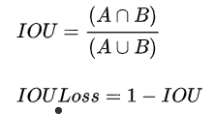

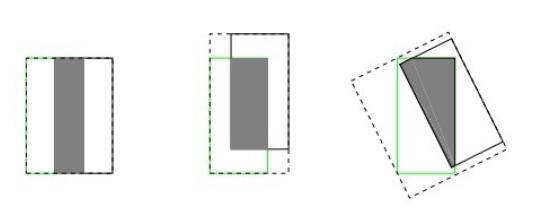

**缺点：**

- 无法优化两个框不相交的情况；
- 无法反映两个框如何相交的。

#### 5.2.2 GIOU Loss（Generalized）
**进化二：不相交时，IOU=0，两个框距离变换，IOU loss不变，改进为GIOU。**

- GIOU Loss，在IOU的基础上引入了预测框和真实框的最小外接矩形。
- 包含时计算得到的IOU、GIOU数值相等，损失函数值与IOUloss 一样，无法很好的衡量其相对的位置关系。
- 同时在计算过程中出现上述情况，预测框在水平或垂直方向优化困难，导致收敛速度慢。

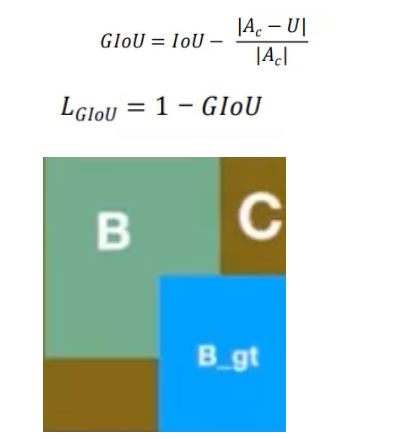

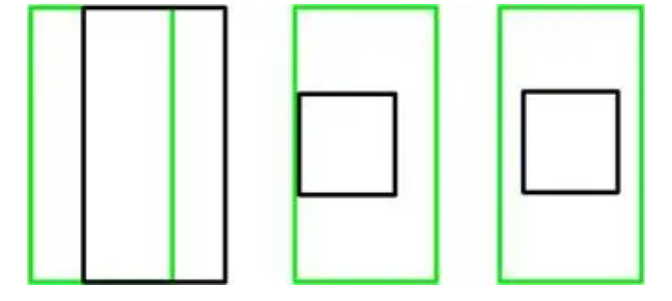

> 当两框完全重合时取最小值0，当两框的边外切时，损失函数值为1；当两框分离且距离很远时，损失函数值为2。

#### 5.2.3 DIoU Loss（Distance）
**进化三：包含时，AUB不变，两个框距离变换，GIOU loss不变，改进为DIOU。**

- d是A框与B框中心点坐标的欧式距离，而c 则是包住它们的最小方框的对角线距离。
- DIoU Loss收敛速度会比GIoU Loss快。
- 问题：中心点重合，但宽高比不同时，DIOU loss不变。

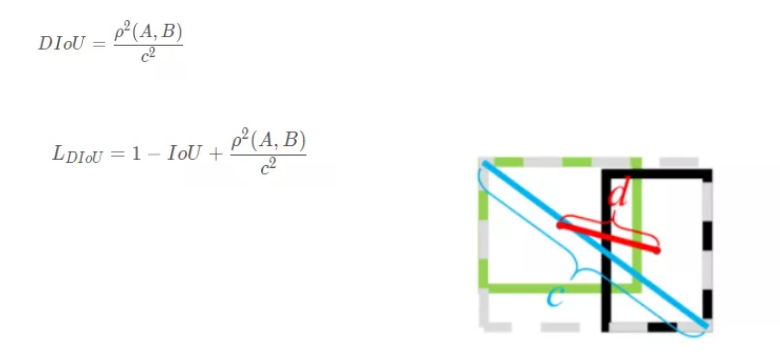

#### 5.2.4 CIOU Loss（Complete）
**进化四：中心点重合，中心点距离不变，DIOU Loss不变，但宽高比不同改进为CIOU。**

- 在两个框中心点重合时，c与d的值都不变。所以此时需要引入框的宽高比。 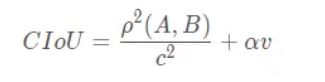

- 其中α 是权重函数，v 用来度量宽高比的一致性： 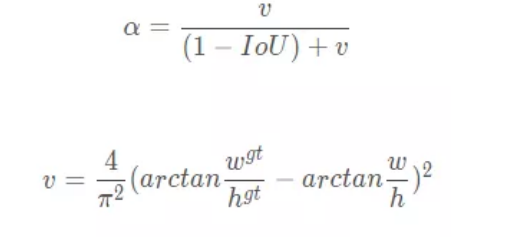

- CIoU Loss公式：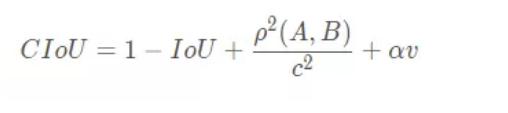

#### 5.2.5 EIOU Loss
**在CIOU的基础上将纵横比拆开，提出了EIOU Loss，并且加入Focal聚焦优质的锚框。**

- EIOU的惩罚项是在CIOU的惩罚项基础上将纵横比的影响因子拆开分别计算目标框和锚框的长和宽，该损失函数包含三个部分：
    - 重叠损失
    - 中心距离损失
    - 宽高损失。
- 前两部分延续CIOU中的方法，但是宽高损失直接使目标盒与锚盒的宽度和高度之差最小，使得收敛速度更快。
- 引入了Focal Loss优化了边界框回归任务中的样本不平衡问题，即减少与目标框重叠较少的大量锚框对BBox 回归的优化贡献，使回归过程专注于高质量锚框。

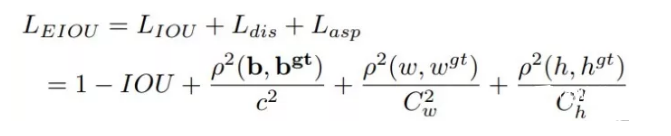

#### 5.2.6 优缺点小结

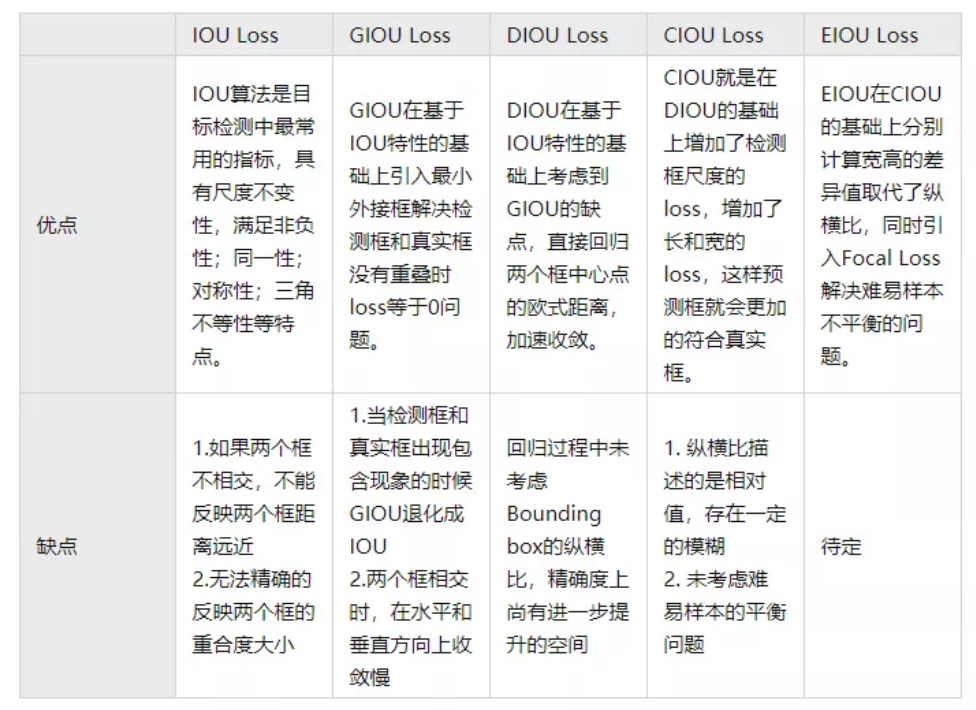

### 5.3 NMS后处理改进
#### 5.3.1 nms回顾
- nms将NMS的滤框过程，写成re-scoring function： 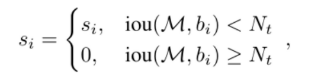
- nms选择将重叠度超过阈值的预测框直接丢弃。

**nms存在的问题：**

- 物体重叠 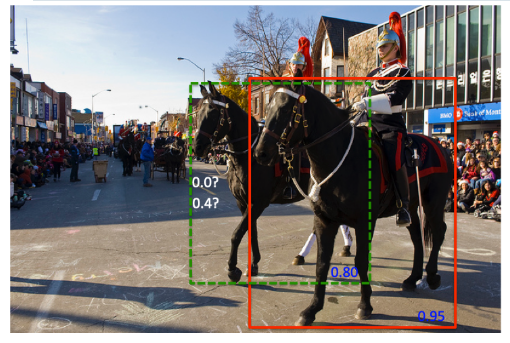
- 并不是所有的框都那么精准 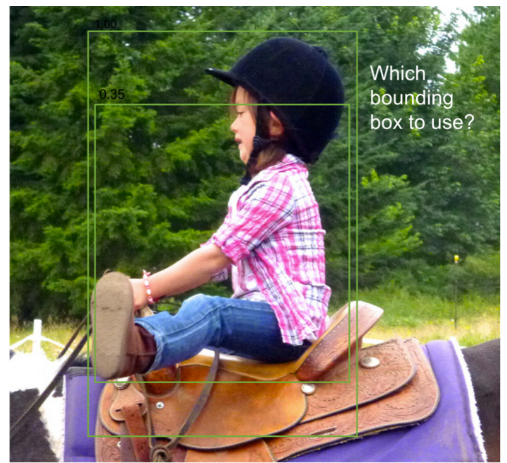

#### 5.3.2 Soft-NMS
**Soft NMS的完整算法流程：**

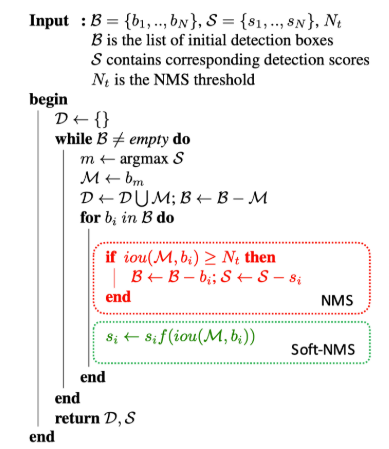

> 红色的部分表示原始NMS算法，绿色部分表示Soft-NMS算法，区别在于，绿色的框只是把si降低了，而不是把bi直接去掉，极端情况下，如果f只返回0，那么等同于普通的NMS。

**Soft-NMS惩罚函数f**

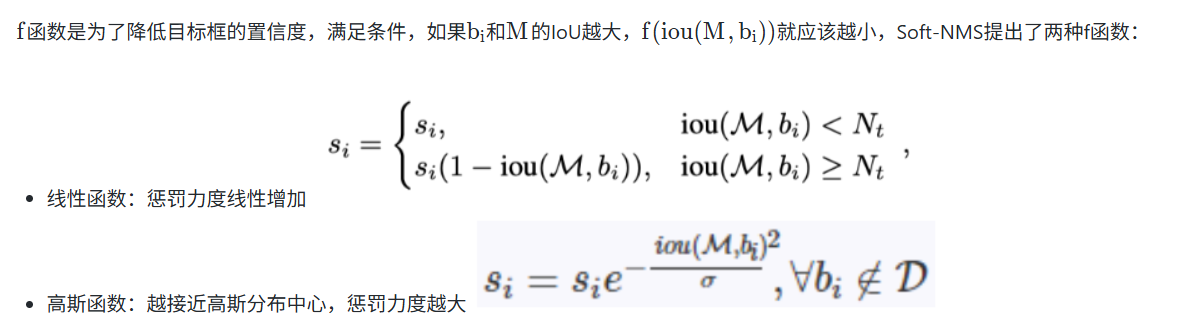

**Soft-NMS效果**

Soft-NMS的效果也比较明显：重叠的物体被更大程度的保留下来，以下是效果图

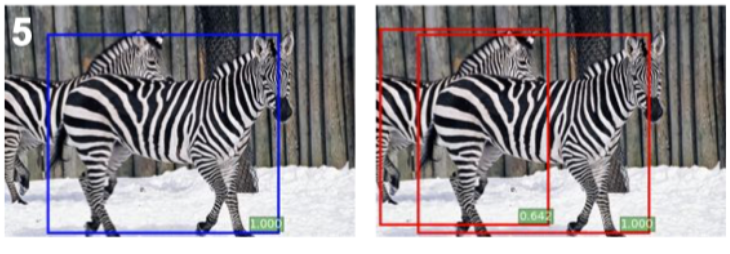

> 不过Soft-NMS还是需要调整阈值的，由于没有“去掉”某些框的操作，因此，最后所有框都会被加入D中，只是那些被去掉的框的置信度明显降低，所以需要一个阈值（通常很小）来过滤D中的输出框，从而输出最后的预测框。

#### 5.3.3 Softer-NMS
Soft-NMS只解决了两个问题中的第一个问题，那么剩下的问题如何解决呢？softer-nms提出两个想法：

- 构建一种IoU的置信度，来建模有多大把握认为当前框和GT是重合的
- 提出一种方法根据IoU置信度加权合并多个框优化最终生成框
- 使用高斯分布对预测框建模：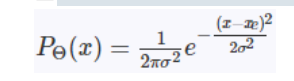
- 使用delta分布对GT框建模：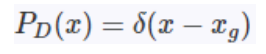

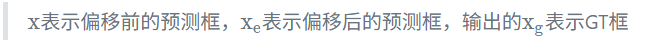

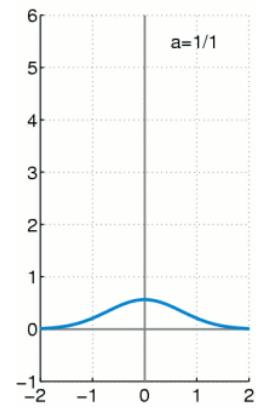

> delta分布是当高斯分布的σ趋于0时的极限分布,当σ越小，曲线越瘦高，当σ非常小的时候，几乎是一条竖直的线，同时σ越小，表示越确定，因此1−σ可以作为置信度

**Softer-NMS需要修改目标检测网络结构**

上面是原始fasterRCNN的结构，下面是softer-nms结构，多加了一个σ预测，也就是boxstd，而Box的预测其实就是公式中的xe

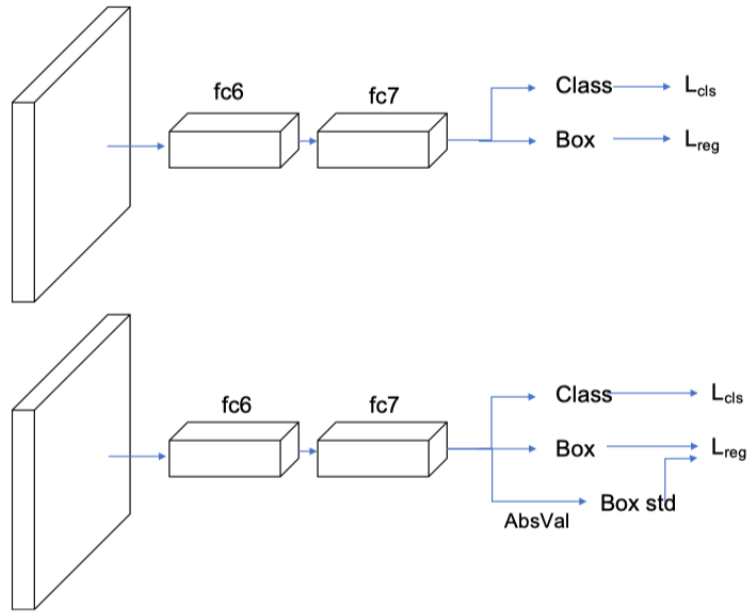

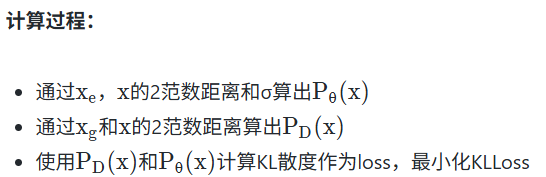

**Softer-NMS算法流程**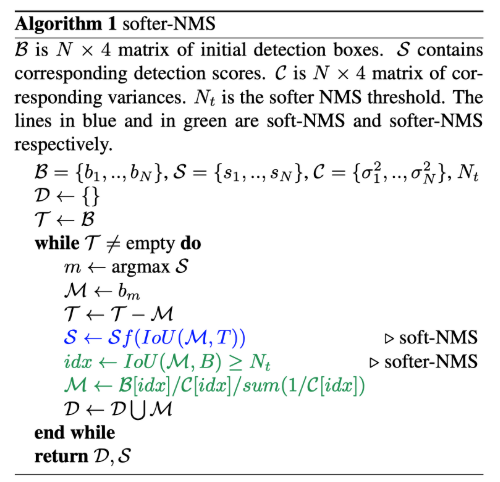



#### 5.4.4 nms小结
- Soft-NMS和Softer-NMS都是基于传统NMS上的改进，目的在于解决目标检测中的物体重叠难以预测，分类分数与IoU不匹配的问题。
- Soft-NMS，能够在不重新训练模型的前提下，只通过修改少量的代码就能带来不少的提升，简单易用。
- Softer-NMS的实现稍显复杂，需要网络重新训练以预测出四个坐标(x1,x2,y1,y2)的坐标置信度，然后用此置信度作为权值加权，实现了”多框合一“。